# Serie de tiempo de flujo solar
### María José Soto Castro A01705840


In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers



In [43]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [44]:
flux_path = '/content/drive/MyDrive/solarFlux/solar_flux_table.txt'

In [45]:
df = pd.read_csv(flux_path,
            sep=r"\s+",          # separa por múltiples espacios
            skiprows=[1])     # ignora la línea de guiones)

Se inicia con el formateo de fechas, las columnas que indican tiempo en este dataset son 4:
- Fluxdate: fecha gregoriana de la medición
- Fluxtime: tiempo con reloj atómico o mundial
- fluxjulian: fecha juliana utilizada para interpretar trancisiones de cielo observable
- Fluxcarrington: fecha descrita en no. de rotaciones que ha hecho el sol desde 9 de noviembre del 1853.

In [46]:

# Convertir columnas numéricas
cols = [
    "fluxjulian",
    "fluxcarrington",
    "fluxobsflux",
    "fluxadjflux",
    "fluxursi"
]

df[cols] = df[cols].astype(float)

print(df.dtypes)

fluxdate            int64
fluxtime            int64
fluxjulian        float64
fluxcarrington    float64
fluxobsflux       float64
fluxadjflux       float64
fluxursi          float64
dtype: object


In [47]:
df.head()

,fluxdate,fluxtime,fluxjulian,fluxcarrington,fluxobsflux,fluxadjflux,fluxursi
0,20041028,170000,2453307.229,2022.605,132.7,130.9,117.8
1,20041028,200000,2453307.354,2022.610,135.8,134.0,120.6
2,20041029,200000,2453308.354,2022.646,130.6,128.8,115.9
3,20041029,230000,2453308.479,2022.651,134.2,132.3,119.1
4,20041030,170000,2453309.229,2022.678,147.9,145.8,131.2


In [48]:
#Cambiar formato de fecha en fluxdate

df["fluxdate"] = pd.to_datetime(
    df["fluxdate"].astype(str),
    format="%Y%m%d"
)

print(df["fluxdate"].head())

0   2004-10-28
1   2004-10-28
2   2004-10-29
3   2004-10-29
4   2004-10-30
Name: fluxdate, dtype: datetime64[ns]


In [49]:
#Cambiar formato de tiempo en fluxtime

df["datetime"] = pd.to_datetime(
    df["fluxdate"].dt.strftime("%Y-%m-%d") +
    " " +
    df["fluxtime"].astype(str).str.zfill(6),
    format="%Y-%m-%d %H%M%S"
)

print(df["datetime"].head())

0   2004-10-28 17:00:00
1   2004-10-28 20:00:00
2   2004-10-29 20:00:00
3   2004-10-29 23:00:00
4   2004-10-30 17:00:00
Name: datetime, dtype: datetime64[ns]


In [50]:
df.head()

,fluxdate,fluxtime,fluxjulian,fluxcarrington,fluxobsflux,fluxadjflux,fluxursi,datetime
0,2004-10-28,170000,2453307.229,2022.605,132.7,130.9,117.8,2004-10-28 17:00:00
1,2004-10-28,200000,2453307.354,2022.610,135.8,134.0,120.6,2004-10-28 20:00:00
2,2004-10-29,200000,2453308.354,2022.646,130.6,128.8,115.9,2004-10-29 20:00:00
3,2004-10-29,230000,2453308.479,2022.651,134.2,132.3,119.1,2004-10-29 23:00:00
4,2004-10-30,170000,2453309.229,2022.678,147.9,145.8,131.2,2004-10-30 17:00:00


In [51]:
df.count()

,0
fluxdate,23595
fluxtime,23595
fluxjulian,23595
fluxcarrington,23595
fluxobsflux,23595
fluxadjflux,23595
fluxursi,23595
datetime,23595


Las columnas de fluxobs, fluxadj y fluxursi son estandarizaciones diferentes del mismo dato de flujo solar. Es necesario utilizar estos 3 para utilizarlos en la astronomía, debido a la variación de instrumentos donde se utilizan.


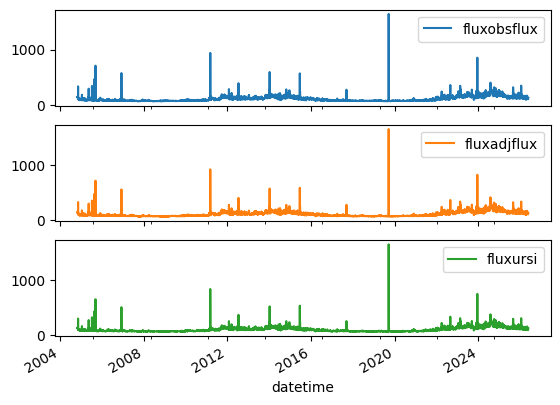

In [52]:
plot_cols = ['fluxobsflux', 'fluxadjflux', 'fluxursi']
plot_features = df[plot_cols]
plot_features.index = df['datetime']
_ = plot_features.plot(subplots=True)




> Se realizan tres mediciones de flujo cada día. Entre marzo y octubre, las mediciones se realizan a las 17:00, 20:00 (mediodía local) y 23:00 UT. Sin embargo, la ubicación en un valle de montaña y una latitud relativamente alta imposibilitan mantener estos horarios durante el resto del año. Por consiguiente, de noviembre a febrero, las mediciones de flujo se realizan a las 18:00, 20:00 y 22:00, para que el Sol esté lo suficientemente alto sobre el horizonte y se pueda realizar una buena medición. (Canada, 2019)



In [53]:
# Crear lags
# 1 día atrás. Cada dia tiene 3 registros
df["lag_day"] = df["fluxadjflux"].shift(3)

# 1 semana atrás
df["lag_week"] = df["fluxadjflux"].shift(21)

# Rotación solar (~27 días)
df["lag_solar_rotation"] = df["fluxadjflux"].shift(81)

# 1 mes atrás
df["lag_month"] = df["fluxadjflux"].shift(90)

# 3 meses atrás
df["lag_3months"] = df["fluxadjflux"].shift(270)

# 1 año atrás
df["lag_year"] = df["fluxadjflux"].shift(1095)

# Eliminar NaNs generados por los lags
df = df.dropna().reset_index(drop=True)

In [54]:
df.head()

,fluxdate,fluxtime,fluxjulian,fluxcarrington,fluxobsflux,fluxadjflux,fluxursi,datetime,lag_day,lag_week,lag_solar_rotation,lag_month,lag_3months,lag_year
0,2005-11-05,200000,2453680.337,2036.284,79.3,77.9,70.1,2005-11-05 20:00:00,76.1,73.1,78.7,79.4,94.9,130.9
1,2005-11-05,220000,2453680.421,2036.288,80.9,79.5,71.6,2005-11-05 22:00:00,77.6,74.3,79.2,79.5,95.6,134.0
2,2005-11-06,180000,2453681.254,2036.318,80.6,79.1,71.2,2005-11-06 18:00:00,76.6,73.9,78.8,78.1,89.3,128.8
3,2005-11-06,200000,2453681.337,2036.321,81.7,80.3,72.3,2005-11-06 20:00:00,77.9,74.5,78.8,78.7,88.9,132.3
4,2005-11-06,220000,2453681.421,2036.324,82.4,80.9,72.8,2005-11-06 22:00:00,79.5,75.7,79.4,79.1,88.9,145.8


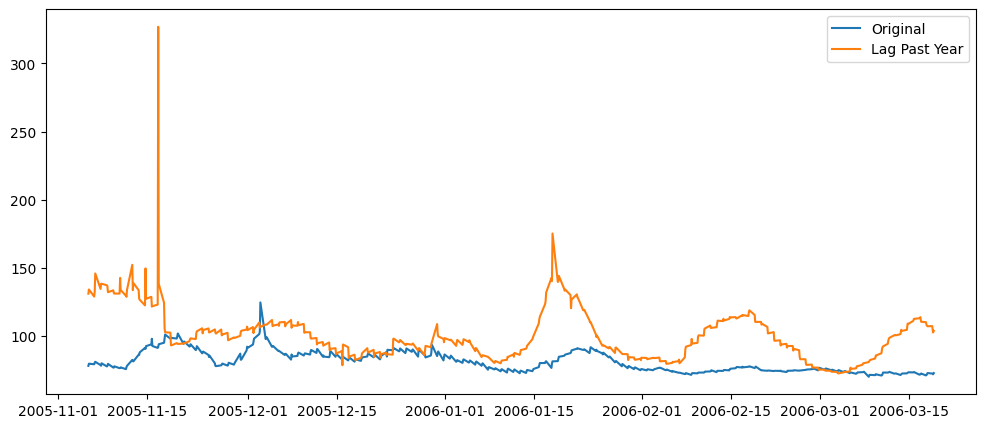

In [55]:
plt.figure(figsize=(12,5))

plt.plot(df["datetime"][:400], df["fluxadjflux"][:400], label="Original")
plt.plot(df["datetime"][:400], df["lag_year"][:400], label="Lag Past Year")

plt.legend()
plt.show()

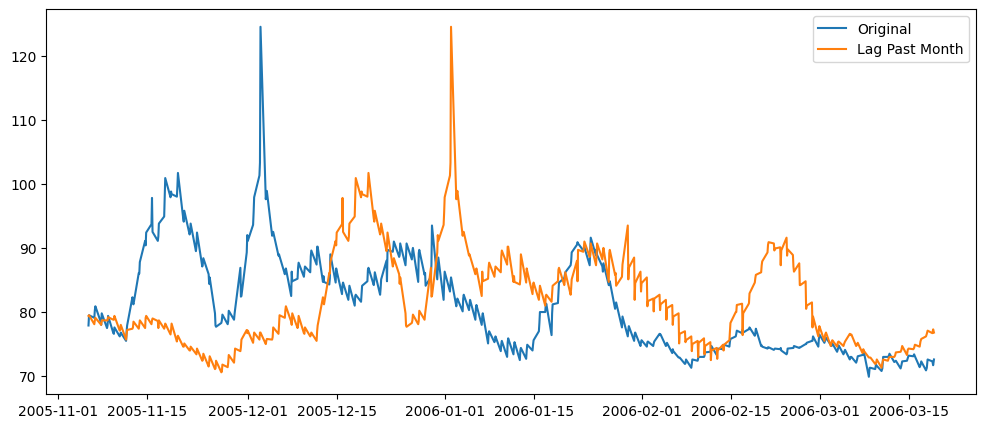

In [56]:

plt.figure(figsize=(12,5))

plt.plot(df["datetime"][:400], df["fluxadjflux"][:400], label="Original")
plt.plot(df["datetime"][:400], df["lag_month"][:400], label="Lag Past Month")

plt.legend()
plt.show()

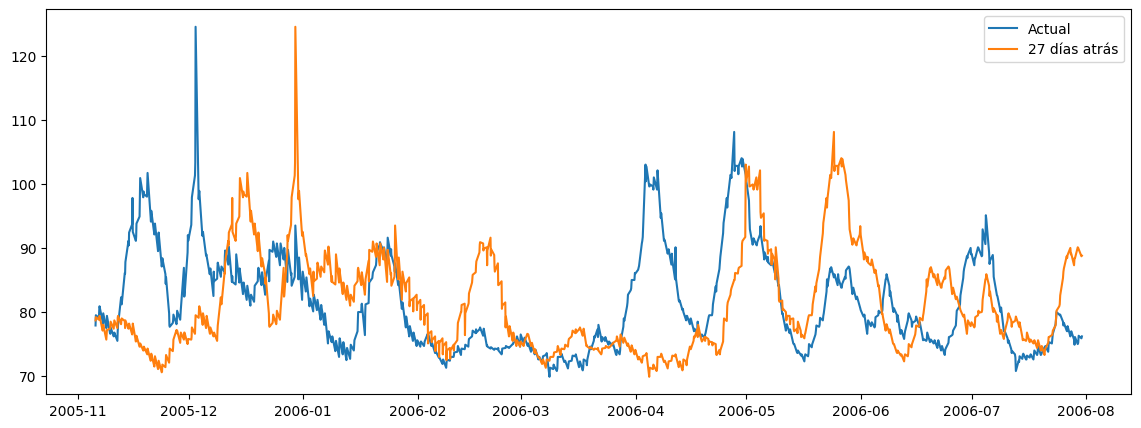

In [57]:
plt.figure(figsize=(14,5))

plt.plot(df["datetime"][:800], df["fluxadjflux"][:800], label="Actual")
plt.plot(df["datetime"][:800], df["lag_solar_rotation"][:800],
         label="27 días atrás")

plt.legend()
plt.show()

# DATA SPLITTING

In [58]:
n = len(df)
train_df = df[0:int(n*0.7)]
val_df = df[int(n*0.7):int(n*0.9)]
test_df = df[int(n*0.9):]

num_features = df.shape[1]

print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(15749, 14)
(4501, 14)
(2250, 14)


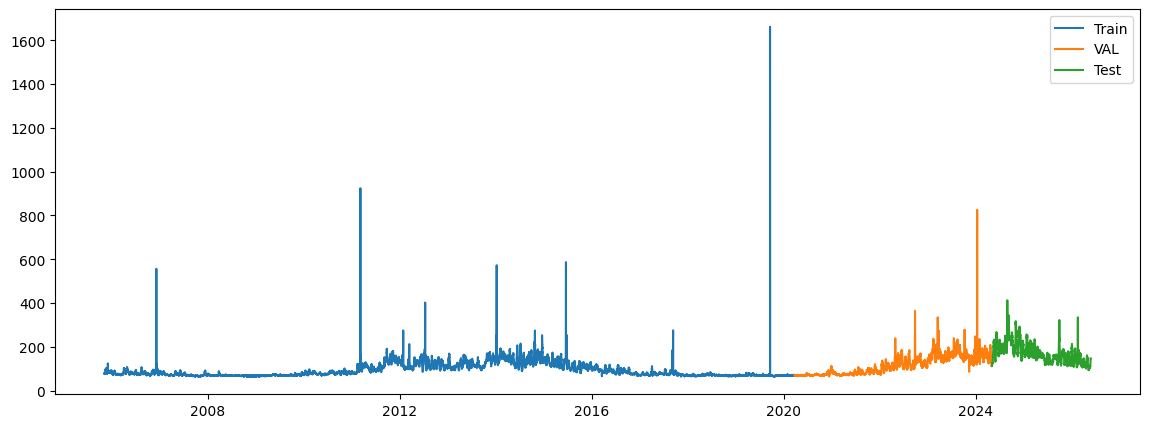

In [59]:
plt.figure(figsize=(14,5))

plt.plot(train_df["datetime"], train_df["fluxadjflux"], label="Train")
plt.plot(val_df["datetime"], val_df["lag_solar_rotation"],
         label="VAL")
plt.plot(test_df["datetime"], test_df["lag_solar_rotation"],
         label="Test")


plt.legend()
plt.show()

# Normalisación de datos
Para normalizar los datos, se aplica RobustScaler de sklearn, debido a la fluctuación de datos extrema en flujo solar en vez de utilizar los percentiles de 25% y 75% y la mediana para prevenir perder los datos extremos.

A comparación de min-max o con desviación estandar, los picos en los datos no son erradicados.

In [60]:

features = [
    "fluxobsflux",
    "fluxadjflux",
    "fluxursi",
    "lag_day",
    "lag_week",
    "lag_solar_rotation",
    "lag_month",
    "lag_3months",
    "lag_year"
]
scaler = RobustScaler()

train_df[features] = scaler.fit_transform(train_df[features])

val_df[features] = scaler.transform(val_df[features])

test_df[features] = scaler.transform(test_df[features])

/tmp/ipykernel_5027/1006806919.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df[features] = scaler.fit_transform(train_df[features])
/tmp/ipykernel_5027/1006806919.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val_df[features] = scaler.transform(val_df[features])
/tmp/ipykernel_5027/1006806919.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: htt

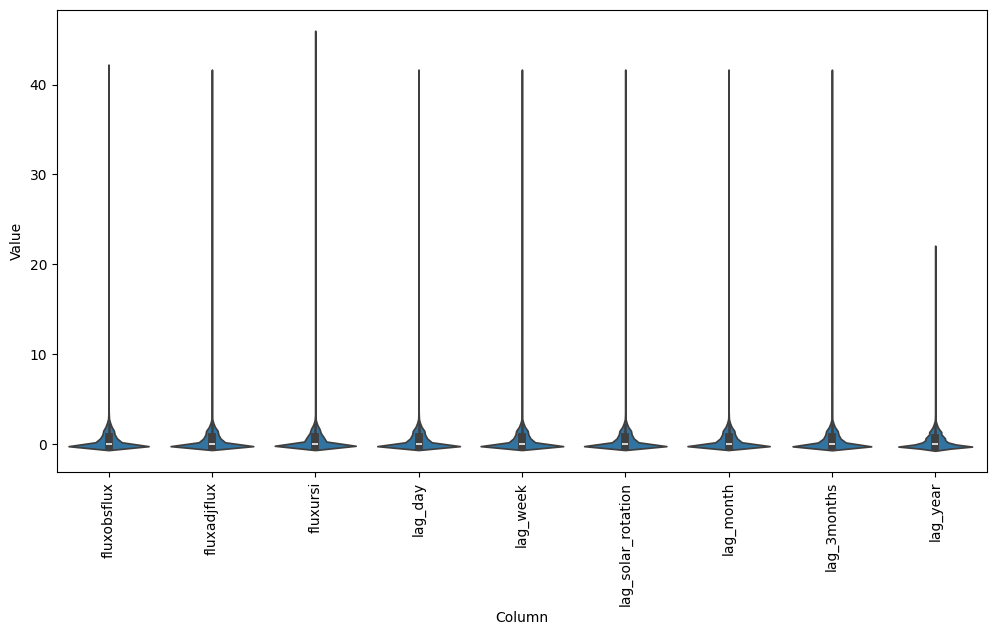

In [61]:
df_plot = train_df[features].melt(
    var_name="Column",
    value_name="Value"
)

plt.figure(figsize=(12,6))

sns.violinplot(
    x="Column",
    y="Value",
    data=df_plot
)

plt.xticks(rotation=90)

plt.show()

Las correlaciones más importantes son entre [fluxobs, fluxadj, fluxursi] y [lag_day, lag_solar_rotation]

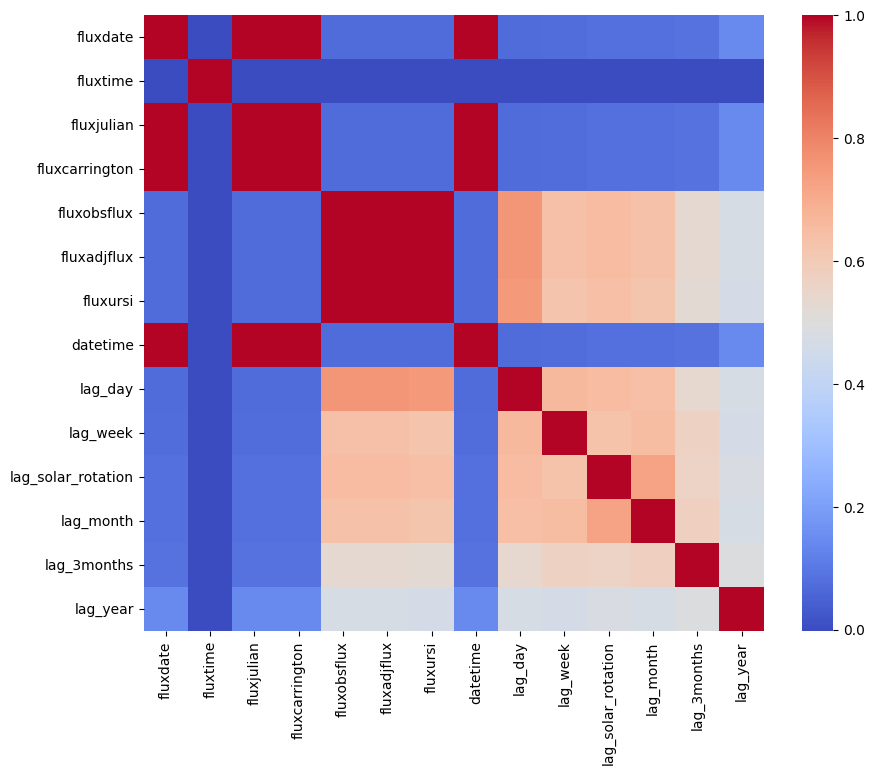

In [62]:
corr = train_df.corr()

plt.figure(figsize=(10,8))

sns.heatmap(corr, cmap="coolwarm")

plt.show()

Los datos no cambian en tendencia, solo en estándar.

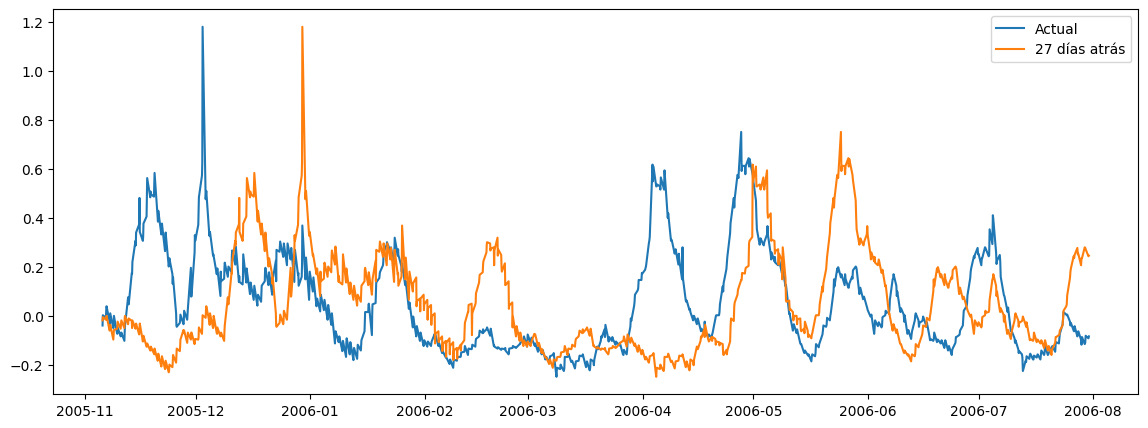

In [63]:
plt.figure(figsize=(14,5))

plt.plot(train_df["datetime"][:800], train_df["fluxadjflux"][:800], label="Actual")
plt.plot(train_df["datetime"][:800], train_df["lag_solar_rotation"][:800],
         label="27 días atrás")

plt.legend()
plt.show()

In [67]:


# Data Preparation  ---

# Assuming flux_path is defined from a previous cell. If not, uncomment and define it:
flux_path = '/content/drive/MyDrive/solarFlux/solar_flux_table.txt'

df = pd.read_csv(flux_path,
            sep=r"\s+",          # separa por múltiples espacios
            skiprows=[1])     # ignora la línea de guiones)

cols = [
    "fluxjulian",
    "fluxcarrington",
    "fluxobsflux",
    "fluxadjflux",
    "fluxursi"
]
df[cols] = df[cols].astype(float)

df["fluxdate"] = pd.to_datetime(
    df["fluxdate"].astype(str),
    format="%Y%m%d"
)

df["datetime"] = pd.to_datetime(
    df["fluxdate"].dt.strftime("%Y-%m-%d") +
    " " +
    df["fluxtime"].astype(str).str.zfill(6),
    format="%Y-%m-%d %H%M%S"
)

# Create lags
df["lag_day"] = df["fluxadjflux"].shift(3)
df["lag_week"] = df["fluxadjflux"].shift(21)
df["lag_solar_rotation"] = df["fluxadjflux"].shift(81)
df["lag_month"] = df["fluxadjflux"].shift(90)
df["lag_3months"] = df["fluxadjflux"].shift(270) # Corrected typo here
df["lag_year"] = df["fluxadjflux"].shift(1095)

# Eliminar NaNs generados por los lags
df = df.dropna().reset_index(drop=True)

# Data Splitting
n = len(df)
train_df = df[0:int(n*0.7)]
val_df = df[int(n*0.7):int(n*0.9)]
test_df = df[int(n*0.9):]

# Normalization
features = [
    "fluxobsflux",
    "fluxadjflux",
    "fluxursi",
    "lag_day",
    "lag_week",
    "lag_solar_rotation",
    "lag_month",
    "lag_3months",
    "lag_year"
]
scaler = RobustScaler()

train_df[features] = scaler.fit_transform(train_df[features])

val_df[features] = scaler.transform(val_df[features])

test_df[features] = scaler.transform(test_df[features])



# Definir history and target sizes
history_size = 3 # Changed to 3, taking the daily 3 takes on the data
target_size = 1  # Predict 1 step into the future

# Preparar data para LSTM


features_for_lstm = [
    "fluxobsflux",
    "fluxadjflux",
    "fluxursi",
    "lag_day",
    "lag_week",
    "lag_solar_rotation",
    "lag_month",
    "lag_3months",
    "lag_year"
]

# Get the index of 'fluxadjflux' in the features_for_lstm list
target_feature_index = features_for_lstm.index('fluxadjflux')

def create_sequences_with_target_index(data, history_size, target_size, target_idx):
    X = []
    y = []
    for i in range(len(data) - history_size - target_size + 1):
        X.append(data[i:(i + history_size), :])
        y.append(data[i + history_size + target_size - 1, target_idx])
    return np.array(X), np.array(y)



# Create sequences for the first model
x_train_scaled, y_train_scaled = create_sequences_with_target_index(
    train_df[features_for_lstm].values,
    history_size,
    target_size,
    target_feature_index
)

print(f"x_train_scaled shape: {x_train_scaled.shape}")
print(f"y_train_scaled shape: {y_train_scaled.shape}")


x_train_scaled shape: (15746, 3, 9)
y_train_scaled shape: (15746,)


/tmp/ipykernel_5027/3652720873.py:62: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df[features] = scaler.fit_transform(train_df[features])
/tmp/ipykernel_5027/3652720873.py:64: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val_df[features] = scaler.transform(val_df[features])
/tmp/ipykernel_5027/3652720873.py:66: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: htt

Model 1 - x_train_scaled shape: (15746, 3, 9)
Model 1 - y_train_scaled shape: (15746,)
Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


493/493 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.2210 - mae: 0.1139 - rmse: 0.4701 - val_loss: 0.1279 - val_mae: 0.1224 - val_rmse: 0.3577
Epoch 2/300
493/493 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.1789 - mae: 0.0682 - rmse: 0.4230 - val_loss: 0.1144 - val_mae: 0.0937 - val_rmse: 0.3382
Epoch 3/300
493/493 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1765 - mae: 0.0645 - rmse: 0.4201 - val_loss: 0.1181 - val_mae: 0.1003 - val_rmse: 0.3437
Epoch 4/300
493/493 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1764 - mae: 0.0639 - rmse: 0.4200 - val_loss: 0.1131 - val_mae: 0.0888 - val_rmse: 0.3362
Epoch 5/300
493/493 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1755 - mae: 0.0619 - rmse: 0.4189 - val_loss: 0.1135 - val_mae: 0.0886 - val_rmse: 0.3369
Epoch 6/300
493/493 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1750 - mae: 0.0608 - rmse: 0.4183 - val_loss: 0.1169 - val_mae: 0.0956 - val_rmse: 0.3419
Epoch 7/300
493/493 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1749 - mae: 0.0606 - rmse: 0.41

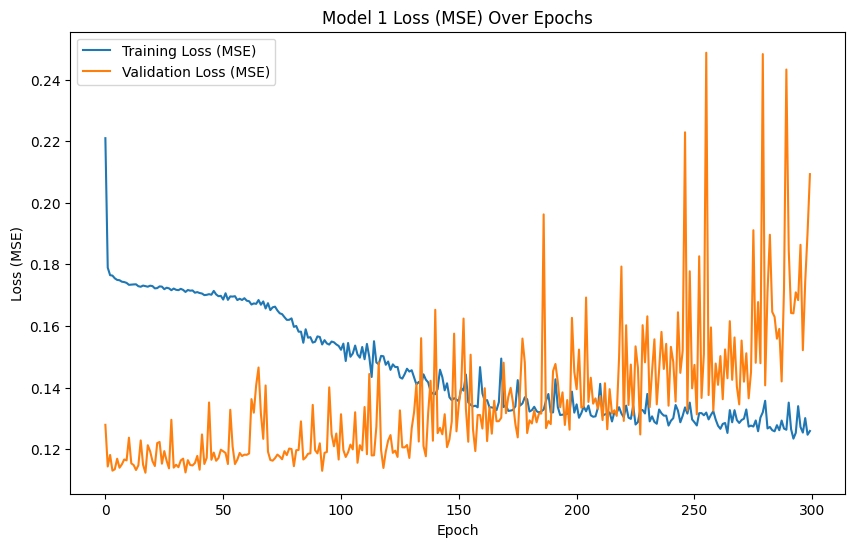

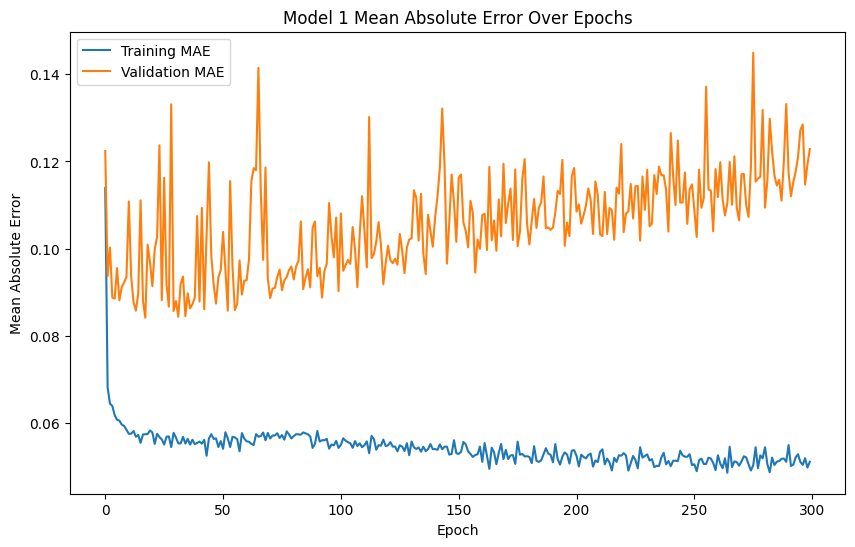

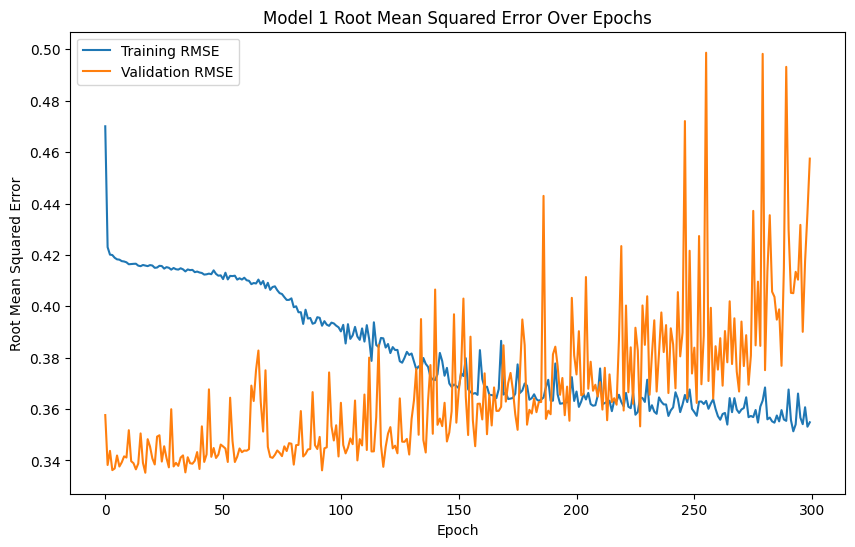

In [76]:
# --- Primer Modelo (history_size = 3) ---

history_size_model1 = 3
target_size = 1

# Preparar datos
x_train_scaled_model1, y_train_scaled_model1 = create_sequences_with_target_index(
    train_df[features_for_lstm].values,
    history_size_model1,
    target_size,
    target_feature_index
)
x_val_scaled_model1, y_val_scaled_model1 = create_sequences_with_target_index(
    val_df[features_for_lstm].values,
    history_size_model1,
    target_size,
    target_feature_index
)
x_test_scaled_model1, y_test_scaled_model1 = create_sequences_with_target_index(
    test_df[features_for_lstm].values,
    history_size_model1,
    target_size,
    target_feature_index
)

print(f"Model 1 - x_train_scaled shape: {x_train_scaled_model1.shape}")
print(f"Model 1 - y_train_scaled shape: {y_train_scaled_model1.shape}")

# Declaración de LSTM
model1 = keras.Sequential([
    layers.LSTM(50, activation='relu', input_shape=(x_train_scaled_model1.shape[1], x_train_scaled_model1.shape[2])),
    layers.Dense(1)
])

# Compilar MSE, MAE y RMSE
optimizer1 = keras.optimizers.Adam(learning_rate=0.001)
model1.compile(optimizer=optimizer1, loss='mse', metrics=['mae', tf.keras.metrics.RootMeanSquaredError(name='rmse')])

# Entrenamiento
history1 = model1.fit(
    x_train_scaled_model1,
    y_train_scaled_model1,
    epochs=300,
    validation_data=(x_val_scaled_model1, y_val_scaled_model1),
    batch_size=32,
    verbose=1
)

print("First LSTM model training complete!")

# Evaluación de TEST
test_results_model1 = model1.evaluate(x_test_scaled_model1, y_test_scaled_model1, verbose=0)

# Plot training history (Loss) for Model 1
plt.figure(figsize=(10, 6))
plt.plot(history1.history['loss'], label='Training Loss (MSE)')
plt.plot(history1.history['val_loss'], label='Validation Loss (MSE)')
#plt.axhline(y=test_results_model1[0], color='r', linestyle='--', label=f'Test Loss (MSE): {test_results_model1[0]:.4f}')
plt.title('Model 1 Loss (MSE) Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

# Plot training history (MAE) for Model 1
plt.figure(figsize=(10, 6))
plt.plot(history1.history['mae'], label='Training MAE')
plt.plot(history1.history['val_mae'], label='Validation MAE')
#plt.axhline(y=test_results_model1[1], color='r', linestyle='--', label=f'Test MAE: {test_results_model1[1]:.4f}')
plt.title('Model 1 Mean Absolute Error Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.show()

# Plot training history (RMSE) for Model 1
plt.figure(figsize=(10, 6))
plt.plot(history1.history['rmse'], label='Training RMSE')
plt.plot(history1.history['val_rmse'], label='Validation RMSE')
#plt.axhline(y=test_results_model1[2], color='r', linestyle='--', label=f'Test RMSE: {test_results_model1[2]:.4f}')
plt.title('Model 1 Root Mean Squared Error Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Root Mean Squared Error')
plt.legend()
plt.show()

71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


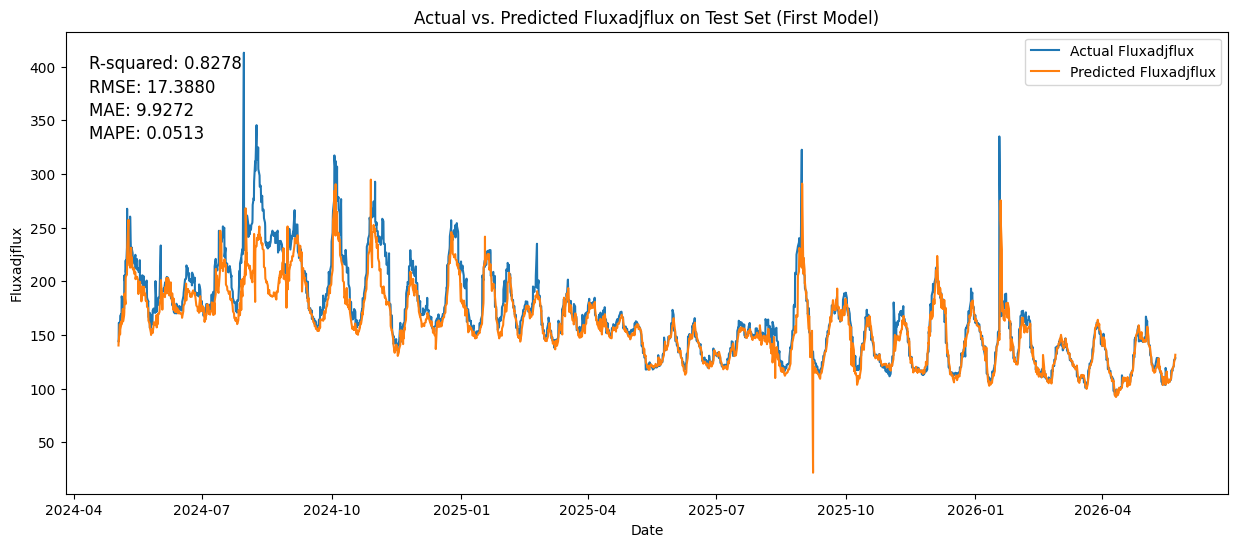


--- Metrics for First Model ---
Mean Squared Error on Test Set: 302.3423
Root Mean Squared Error on Test Set: 17.3880
Mean Absolute Error on Test Set: 9.9272
Mean Absolute Percentage Error on Test Set: 0.0513
R-squared on Test Set: 0.8278


In [77]:
# Predicciones Modelo 1
test_predictions_model1 = model1.predict(x_test_scaled_model1).flatten()

# Create a dummy array with zeros for all features, then place y_test_scaled at the target_feature_index
dummy_y_test_model1 = np.zeros((len(y_test_scaled_model1), len(features)))
dummy_y_test_model1[:, target_feature_index] = y_test_scaled_model1
actual_fluxadjflux_model1 = scaler.inverse_transform(dummy_y_test_model1)[:, target_feature_index]

dummy_predictions_model1 = np.zeros((len(test_predictions_model1), len(features)))
dummy_predictions_model1[:, target_feature_index] = test_predictions_model1
predicted_fluxadjflux_model1 = scaler.inverse_transform(dummy_predictions_model1)[:, target_feature_index]

# Plot actual vs. predicted values for Model 1
plt.figure(figsize=(15, 6))
plt.plot(df['datetime'][len(train_df) + len(val_df) + history_size_model1 - 1:].head(len(actual_fluxadjflux_model1)), actual_fluxadjflux_model1, label='Actual Fluxadjflux')
plt.plot(df['datetime'][len(train_df) + len(val_df) + history_size_model1 - 1:].head(len(predicted_fluxadjflux_model1)), predicted_fluxadjflux_model1, label='Predicted Fluxadjflux')
plt.title('Actual vs. Predicted Fluxadjflux on Test Set (First Model)')
plt.xlabel('Date')
plt.ylabel('Fluxadjflux')
plt.legend()

# Calculate metrics for Model 1
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

mse1 = mean_squared_error(actual_fluxadjflux_model1, predicted_fluxadjflux_model1)
mae1 = mean_absolute_error(actual_fluxadjflux_model1, predicted_fluxadjflux_model1)
rmse1 = np.sqrt(mse1)
r2_1 = r2_score(actual_fluxadjflux_model1, predicted_fluxadjflux_model1)
mape1 = mean_absolute_percentage_error(actual_fluxadjflux_model1, predicted_fluxadjflux_model1)

# Add R-squared, RMSE, MAE, and MAPE values to the plot for Model 1
plt.text(0.02, 0.95, f'R-squared: {r2_1:.4f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')
plt.text(0.02, 0.90, f'RMSE: {rmse1:.4f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')
plt.text(0.02, 0.85, f'MAE: {mae1:.4f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')
plt.text(0.02, 0.80, f'MAPE: {mape1:.4f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')

plt.show()

print(f"\n--- Metrics for First Model ---")
print(f"Mean Squared Error on Test Set: {mse1:.4f}")
print(f"Root Mean Squared Error on Test Set: {rmse1:.4f}")
print(f"Mean Absolute Error on Test Set: {mae1:.4f}")
print(f"Mean Absolute Percentage Error on Test Set: {mape1:.4f}")
print(f"R-squared on Test Set: {r2_1:.4f}")


Model 2 - x_train_scaled shape: (15746, 3, 9)
Model 2 - y_train_scaled shape: (15746,)
Epoch 1/225


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


329/329 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 0.2420 - mae: 0.1582 - rmse: 0.4919 - val_loss: 0.1283 - val_mae: 0.1280 - val_rmse: 0.3582
Epoch 2/225
329/329 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.1826 - mae: 0.0820 - rmse: 0.4273 - val_loss: 0.1222 - val_mae: 0.1151 - val_rmse: 0.3496
Epoch 3/225
329/329 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.1792 - mae: 0.0745 - rmse: 0.4233 - val_loss: 0.1176 - val_mae: 0.1059 - val_rmse: 0.3430
Epoch 4/225
329/329 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.1787 - mae: 0.0730 - rmse: 0.4228 - val_loss: 0.1197 - val_mae: 0.1076 - val_rmse: 0.3460
Epoch 5/225
329/329 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.1774 - mae: 0.0691 - rmse: 0.4212 - val_loss: 0.1127 - val_mae: 0.0970 - val_rmse: 0.3357
Epoch 6/225
329/329 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.1763 - mae: 0.0682 - rmse: 0.4198 - val_loss: 0.1114 - val_mae: 0.0946 - val_rmse: 0.3338
Epoch 7/225
329/329 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.1762 - mae: 0.0684 - rmse: 0

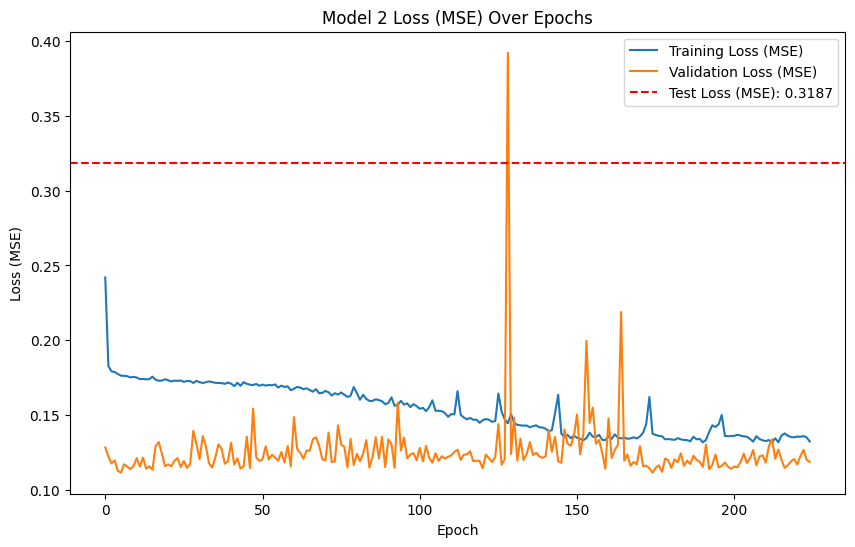

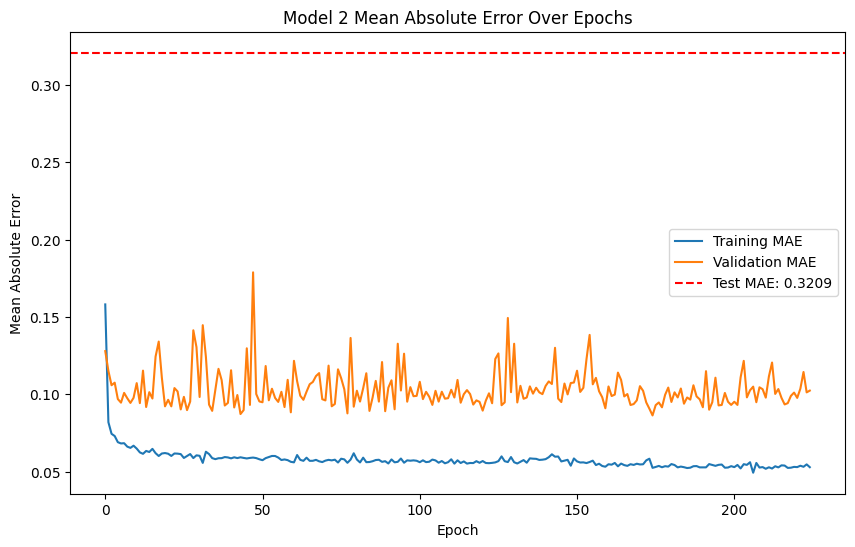

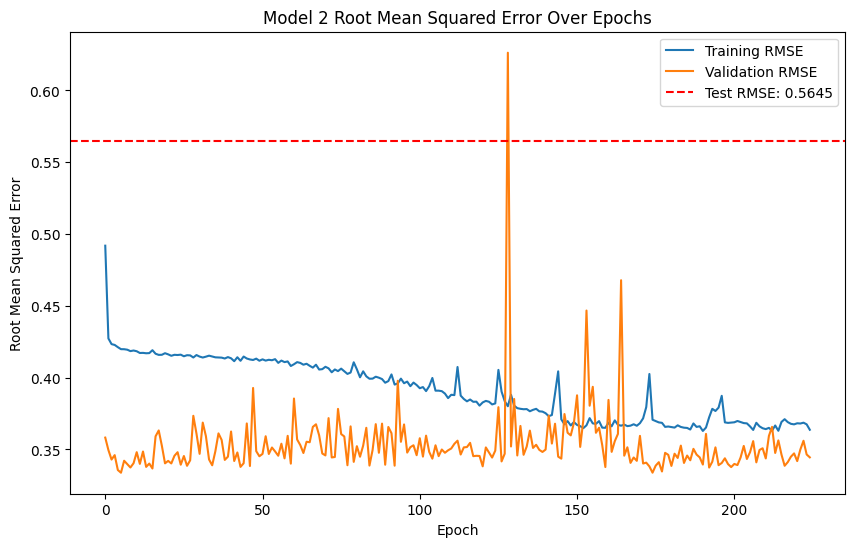

In [78]:
# --- Segundo Modelo (history_size = 9, 3x LSTM 24 units) ---
#(Jerse & Marcucci, 2024)


history_size_model2 = 3

# Preparara datos
x_train_scaled_model2, y_train_scaled_model2 = create_sequences_with_target_index(
    train_df[features_for_lstm].values,
    history_size_model2,
    target_size,
    target_feature_index
)
x_val_scaled_model2, y_val_scaled_model2 = create_sequences_with_target_index(
    val_df[features_for_lstm].values,
    history_size_model2,
    target_size,
    target_feature_index
)
x_test_scaled_model2, y_test_scaled_model2 = create_sequences_with_target_index(
    test_df[features_for_lstm].values,
    history_size_model2,
    target_size,
    target_feature_index
)

print(f"\nModel 2 - x_train_scaled shape: {x_train_scaled_model2.shape}")
print(f"Model 2 - y_train_scaled shape: {y_train_scaled_model2.shape}")

# Declarar modelo
n_batch = 48
model2 = keras.Sequential([
    layers.LSTM(
        24,
        activation='tanh',
        return_sequences=True,
        input_shape=(x_train_scaled_model2.shape[1], x_train_scaled_model2.shape[2])
    ),
    layers.LSTM(
        24,
        activation='tanh',
        return_sequences=True
    ),
    layers.LSTM(
        24,
        activation='tanh'
    ),
    layers.Dense(1)
])

# Compilar metricas MSE, MAE Y RMSE
optimizer2 = keras.optimizers.Adam(learning_rate=0.001)
model2.compile(optimizer=optimizer2, loss='mse', metrics=['mae', tf.keras.metrics.RootMeanSquaredError(name='rmse')])

# Entrenar modelo
history2 = model2.fit(
    x_train_scaled_model2,
    y_train_scaled_model2,
    epochs=225,
    validation_data=(x_val_scaled_model2, y_val_scaled_model2),
    batch_size=48,
    verbose=1
)

print("Second LSTM model training complete!")

# Evaluate the model 2 on the test set to get test metrics for horizontal lines
test_results_model2 = model2.evaluate(x_test_scaled_model2, y_test_scaled_model2, verbose=0)

# Plot training history (Loss) for Model 2
plt.figure(figsize=(10, 6))
plt.plot(history2.history['loss'], label='Training Loss (MSE)')
plt.plot(history2.history['val_loss'], label='Validation Loss (MSE)')
plt.axhline(y=test_results_model2[0], color='r', linestyle='--', label=f'Test Loss (MSE): {test_results_model2[0]:.4f}')
plt.title('Model 2 Loss (MSE) Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

# Plot training history (MAE) for Model 2
plt.figure(figsize=(10, 6))
plt.plot(history2.history['mae'], label='Training MAE')
plt.plot(history2.history['val_mae'], label='Validation MAE')
plt.axhline(y=test_results_model2[1], color='r', linestyle='--', label=f'Test MAE: {test_results_model2[1]:.4f}')
plt.title('Model 2 Mean Absolute Error Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.show()

# Plot training history (RMSE) for Model 2
plt.figure(figsize=(10, 6))
plt.plot(history2.history['rmse'], label='Training RMSE')
plt.plot(history2.history['val_rmse'], label='Validation RMSE')
plt.axhline(y=test_results_model2[2], color='r', linestyle='--', label=f'Test RMSE: {test_results_model2[2]:.4f}')
plt.title('Model 2 Root Mean Squared Error Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Root Mean Squared Error')
plt.legend()
plt.show()

71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


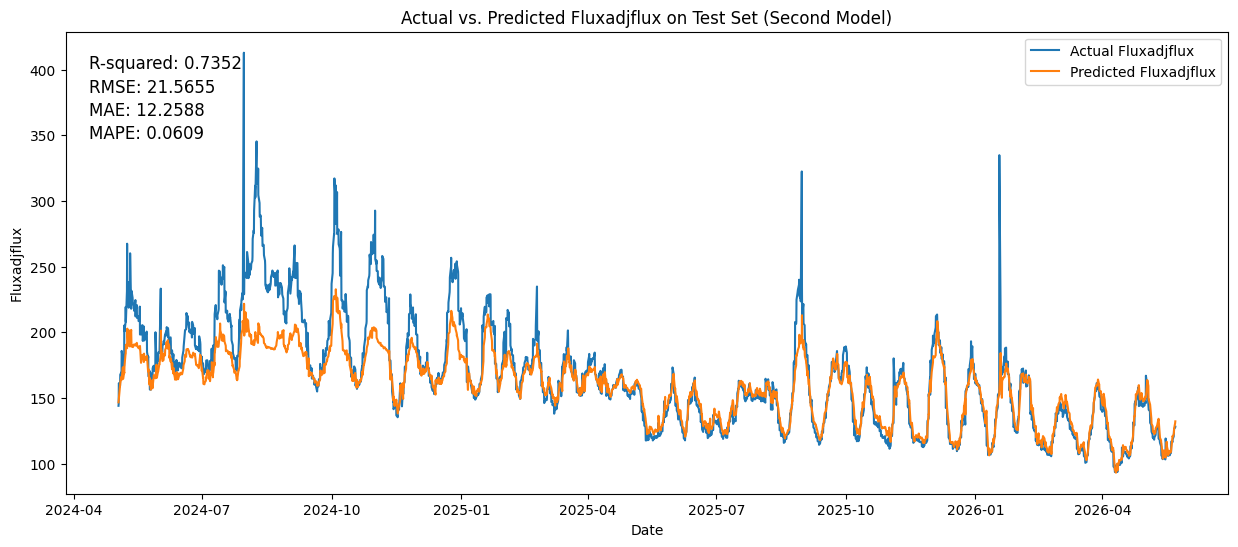


--- Metrics for Second Model ---
Mean Squared Error on Test Set: 465.0696
Root Mean Squared Error on Test Set: 21.5655
Mean Absolute Error on Test Set: 12.2588
Mean Absolute Percentage Error on Test Set: 0.0609
R-squared on Test Set: 0.7352


In [79]:
# Predicciones para modelo
test_predictions_model2 = model2.predict(x_test_scaled_model2).flatten()

# Create a dummy array with zeros for all features, then place y_test_scaled at the target_feature_index
dummy_y_test_model2 = np.zeros((len(y_test_scaled_model2), len(features)))
dummy_y_test_model2[:, target_feature_index] = y_test_scaled_model2
actual_fluxadjflux_model2 = scaler.inverse_transform(dummy_y_test_model2)[:, target_feature_index]

dummy_predictions_model2 = np.zeros((len(test_predictions_model2), len(features)))
dummy_predictions_model2[:, target_feature_index] = test_predictions_model2
predicted_fluxadjflux_model2 = scaler.inverse_transform(dummy_predictions_model2)[:, target_feature_index]

# Plot actual vs. predicted values for Model 2
plt.figure(figsize=(15, 6))
plt.plot(df['datetime'][len(train_df) + len(val_df) + history_size_model2 - 1:].head(len(actual_fluxadjflux_model2)), actual_fluxadjflux_model2, label='Actual Fluxadjflux')
plt.plot(df['datetime'][len(train_df) + len(val_df) + history_size_model2 - 1:].head(len(predicted_fluxadjflux_model2)), predicted_fluxadjflux_model2, label='Predicted Fluxadjflux')
plt.title('Actual vs. Predicted Fluxadjflux on Test Set (Second Model)')
plt.xlabel('Date')
plt.ylabel('Fluxadjflux')
plt.legend()

# Calculate metrics for Model 2
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

mse2 = mean_squared_error(actual_fluxadjflux_model2, predicted_fluxadjflux_model2)
mae2 = mean_absolute_error(actual_fluxadjflux_model2, predicted_fluxadjflux_model2)
rmse2 = np.sqrt(mse2)
r2_2 = r2_score(actual_fluxadjflux_model2, predicted_fluxadjflux_model2)
mape2 = mean_absolute_percentage_error(actual_fluxadjflux_model2, predicted_fluxadjflux_model2)

# Add R-squared, RMSE, MAE, and MAPE values to the plot for Model 2
plt.text(0.02, 0.95, f'R-squared: {r2_2:.4f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')
plt.text(0.02, 0.90, f'RMSE: {rmse2:.4f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')
plt.text(0.02, 0.85, f'MAE: {mae2:.4f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')
plt.text(0.02, 0.80, f'MAPE: {mape2:.4f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')

plt.show()

print(f"\n--- Metrics for Second Model ---")
print(f"Mean Squared Error on Test Set: {mse2:.4f}")
print(f"Root Mean Squared Error on Test Set: {rmse2:.4f}")
print(f"Mean Absolute Error on Test Set: {mae2:.4f}")
print(f"Mean Absolute Percentage Error on Test Set: {mape2:.4f}")
print(f"R-squared on Test Set: {r2_2:.4f}")

In [ ]:
model1.save('model1.h5')

from google.colab import files
files.download('model1.h5')